<a href="https://colab.research.google.com/github/radzhanarabdanova-dotcom/air-quality-in-responses-of-a-gas-multisensor-device-from-italian-city/blob/main/air_quality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1.Title & Approuch
#Air Quality Analysis: Italian City Case Study
# Approach: Following the research methodology, I will start by creating a "beachhead" by loading the Air Quality dataset from Kaggle
# into Google Colab. I will perform EDA to handle sensor errors, use feature engineering to create a proper time-series index, and apply
# domain knowledge to interpret how urban cycles affect pollution levels.

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
#2.Code cell

In [4]:
df = pd.read_csv("AirQuality.csv", sep=';', decimal = ',')
df = df.dropna(axis=1, how='all').dropna(axis=0, how='all')

In [5]:
df

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9352,04/04/2005,10.00.00,3.1,1314.0,-200.0,13.5,1101.0,472.0,539.0,190.0,1374.0,1729.0,21.9,29.3,0.7568
9353,04/04/2005,11.00.00,2.4,1163.0,-200.0,11.4,1027.0,353.0,604.0,179.0,1264.0,1269.0,24.3,23.7,0.7119
9354,04/04/2005,12.00.00,2.4,1142.0,-200.0,12.4,1063.0,293.0,603.0,175.0,1241.0,1092.0,26.9,18.3,0.6406
9355,04/04/2005,13.00.00,2.1,1003.0,-200.0,9.5,961.0,235.0,702.0,156.0,1041.0,770.0,28.3,13.5,0.5139


In [6]:
from numpy import nan
df = df.replace(-200, nan)

In [9]:
df


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9352,04/04/2005,10.00.00,3.1,1314.0,NaN,13.5,1101.0,472.0,539.0,190.0,1374.0,1729.0,21.9,29.3,0.7568
9353,04/04/2005,11.00.00,2.4,1163.0,NaN,11.4,1027.0,353.0,604.0,179.0,1264.0,1269.0,24.3,23.7,0.7119
9354,04/04/2005,12.00.00,2.4,1142.0,NaN,12.4,1063.0,293.0,603.0,175.0,1241.0,1092.0,26.9,18.3,0.6406
9355,04/04/2005,13.00.00,2.1,1003.0,NaN,9.5,961.0,235.0,702.0,156.0,1041.0,770.0,28.3,13.5,0.5139


In [15]:
df['DateTime'] = pd.to_datetime(df['Date'] + " " + df['Time'], format= '%d/%m/%Y %H.%M.%S')
df = df.drop(['Date','Time'],axis=1)
df.set_index('DateTime', inplace=True)

In [ ]:
#3.Visual Analysis
#How does air pollution fluctuate during a typical day?
#I expect to see peaks during rush hours.

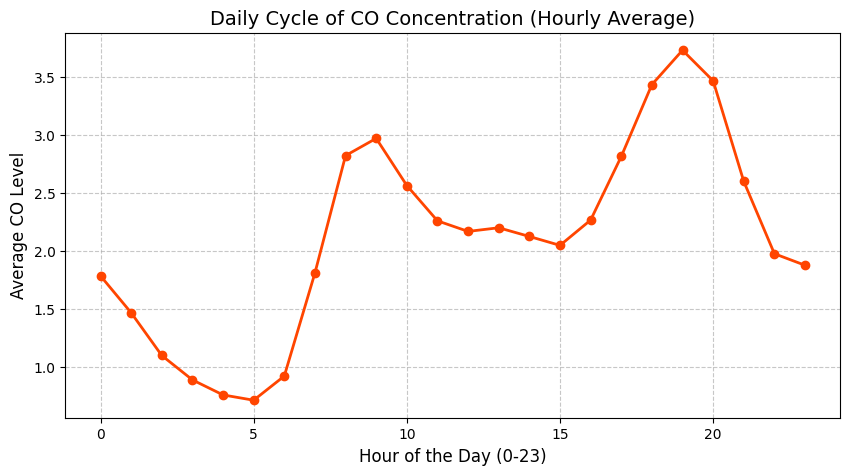

In [16]:

hourly_co = df.groupby(df.index.hour)['CO(GT)'].mean()


plt.figure(figsize=(10, 5))
hourly_co.plot(kind='line', marker='o', color='orangered', linewidth=2)

# Adding titles and labels in English for the final report
plt.title('Daily Cycle of CO Concentration (Hourly Average)', fontsize=14)
plt.xlabel('Hour of the Day (0-23)', fontsize=12)
plt.ylabel('Average CO Level', fontsize=12)

# Adding a grid for better readability as shown in professional EDA examples
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

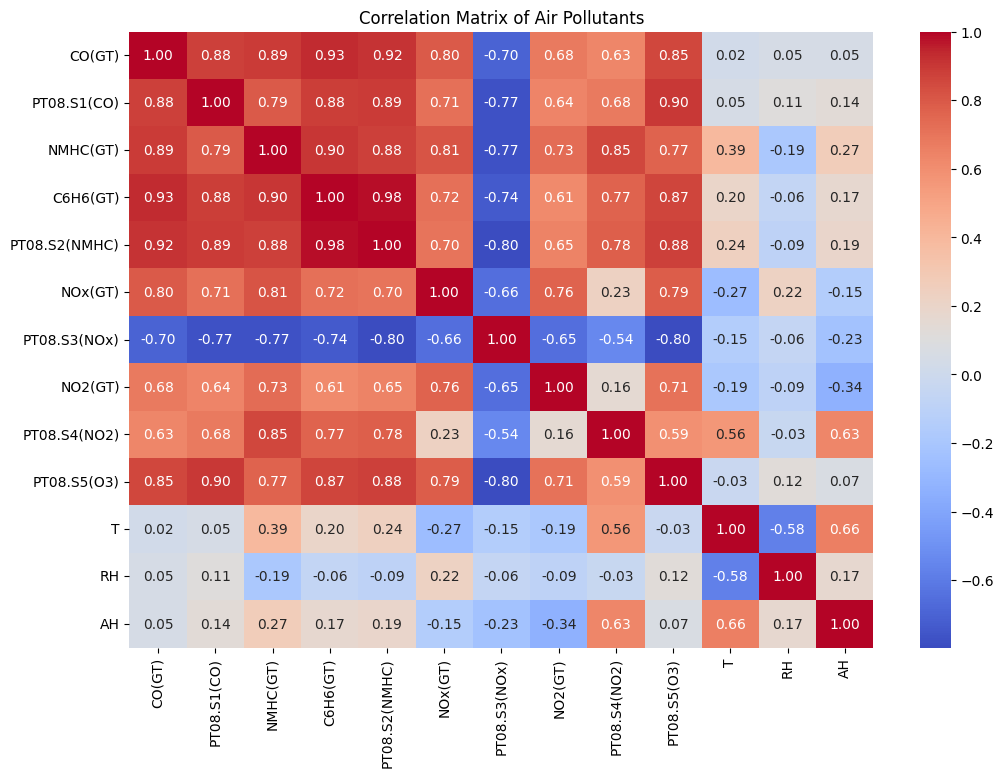

In [17]:
# Create a correlation matrix to see how pollutants relate to each other
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr()

# Plotting the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Air Pollutants')
plt.show()

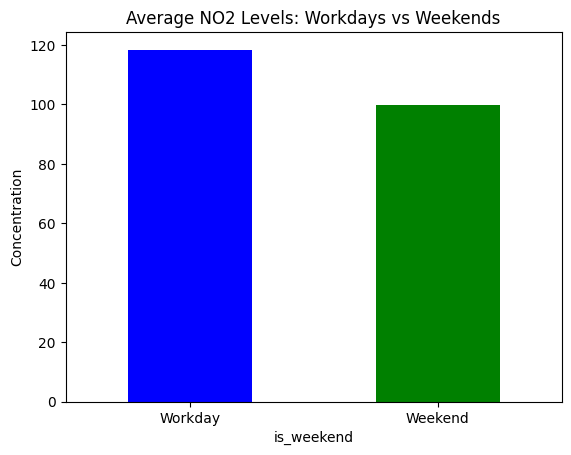

In [18]:

df['is_weekend'] = df.index.weekday >= 5


comparison = df.groupby('is_weekend')['NO2(GT)'].mean()


comparison.plot(kind='bar', color=['blue', 'green'])
plt.xticks([0, 1], ['Workday', 'Weekend'], rotation=0)
plt.title('Average NO2 Levels: Workdays vs Weekends')
plt.ylabel('Concentration')
plt.show()

In [ ]:
# 4. Final Insights

Final Conclusions:
1. Correlation: High correlation between CO, Benzene, and NO2 confirms that vehicle traffic is the main pollution source.
2. Seasonality: The hourly peaks at 8:00 and 19:00 match urban commuting patterns.
3. Methodology: By using Python and Pandas, I achieved the same EDA and Feature Engineering goals as the R-based example.